# Response Clarity Classification: microsoft/deberta-v3-base

**Student ID:** sdi2200160  
**Course:** Artificial Intelligence II - Deep Learning for NLP  
**Assignment:** Homework 2 - Transformer Fine-Tuning

This notebook keeps the same high-level pipeline as HW1, but replaces handcrafted text features with a pretrained tokenizer and replaces Logistic Regression with a transformer classifier trained through an explicit PyTorch loop.

## Runtime Checks

This notebook is designed to run both locally and on Kaggle, but the runtime assumptions are slightly different.

- Local Jupyter or VS Code: the notebook should use the repo `.venv` kernel. The setup cell prints `sys.executable` so we can confirm that the active kernel really matches the environment where the project dependencies were installed.
- Kaggle: enable `GPU` before training. Keep `Internet` enabled for the first run so the QEvasion dataset and the pretrained transformer weights can be downloaded.
- The setup cell below is idempotent. It installs only the missing runtime packages we rely on, then prints a short environment summary so we can debug kernel or dependency issues early instead of failing halfway through the notebook.


In [1]:
from __future__ import annotations

import importlib
import importlib.util
import os
from pathlib import Path
import platform
import subprocess
import sys

os.environ.setdefault('TOKENIZERS_PARALLELISM', 'false')

IS_KAGGLE = bool(os.environ.get('KAGGLE_KERNEL_RUN_TYPE')) or Path('/kaggle').exists()
REQUIRED_RUNTIME = {
    'datasets': 'datasets>=2.14.6',
    'transformers': 'transformers>=5.0.0',
    'sentencepiece': 'sentencepiece',
}
CORE_MODULES = ('numpy', 'pandas', 'sklearn', 'matplotlib', 'torch')


def module_exists(module_name: str) -> bool:
    return importlib.util.find_spec(module_name) is not None


def ensure_package(module_name: str, pip_spec: str) -> None:
    if module_exists(module_name):
        print(f'[ok] {module_name} already available')
        return

    print(f'[install] {pip_spec}')
    try:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pip_spec])
    except subprocess.CalledProcessError as error:
        raise RuntimeError(
            f'Failed to install {pip_spec}. If this is Kaggle, enable Internet for the first run.'
        ) from error

    importlib.invalidate_caches()
    if not module_exists(module_name):
        raise RuntimeError(f'Installed {pip_spec}, but {module_name} is still unavailable.')


for module_name, pip_spec in REQUIRED_RUNTIME.items():
    ensure_package(module_name, pip_spec)

missing_core = [module_name for module_name in CORE_MODULES if not module_exists(module_name)]
if missing_core:
    raise ImportError(
        'Missing core dependencies in the active kernel: '
        + ', '.join(missing_core)
        + '. Switch to the project .venv locally or install them in the current runtime.'
    )

import datasets
import torch
import transformers

print(f'Python:       {sys.version.split()[0]}')
print(f'Interpreter:  {sys.executable}')
print(f'Platform:     {platform.platform()}')
print(f'Kaggle:       {IS_KAGGLE}')
print(f'torch:        {torch.__version__} | CUDA available: {torch.cuda.is_available()}')
print(f'transformers: {transformers.__version__}')
print(f'datasets:     {datasets.__version__}')

if IS_KAGGLE:
    if torch.cuda.is_available():
        print('Kaggle GPU is ready. The first run may still download the dataset and pretrained weights.')
    else:
        print('Enable GPU in Kaggle notebook settings before running the training cells.')
elif '.venv' not in sys.executable:
    print('Warning: this kernel is not using the repo .venv. Switch kernels if the versions do not match your shell.')


[ok] datasets already available
[ok] transformers already available
[ok] sentencepiece already available
Python:       3.12.12
Interpreter:  /usr/bin/python3
Platform:     Linux-6.6.113+-x86_64-with-glibc2.35
Kaggle:       True
torch:        2.10.0+cu128 | CUDA available: True
transformers: 5.0.0
datasets:     4.8.3
Kaggle GPU is ready. The first run may still download the dataset and pretrained weights.


In [2]:
from __future__ import annotations

import functools
import itertools
import os
import random
from pathlib import Path

os.environ.setdefault('PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION', 'python')

import datasets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn.base
import sklearn.metrics
import sklearn.model_selection
import sklearn.preprocessing
import torch
import torch.utils.data
import transformers
from IPython.display import Markdown, display

## 1. Setup and Configuration

We keep a single shared training recipe for all three required models. The only tuning is the same small 2 x 3 sanity sweep for each model over `epochs in {3, 4}` and `max_length in {128, 256, 384}`.

In [3]:
RANDOM_STATE = 42
DEVICE = torch.device('cuda')

MODELS = {
    'bert': 'bert-base-uncased',
    'distilbert': 'distilbert-base-uncased',
    'deberta': 'microsoft/deberta-v3-base',
}

DEFAULT_CONFIG = {
    'batch_size': 16,
    'learning_rate': 2e-5,
    'weight_decay': 0.01,
    'num_epochs': 4,
    'max_length': 256,
    'max_grad_norm': 1.0,
    'val_frac': 0.15,
}

SWEEP_GRID = {
    'num_epochs': (3, 4),
    'max_length': (128, 256, 384),
}

MODEL_KEY = 'deberta'
MODEL_NAME = MODELS[MODEL_KEY]
NOTEBOOK_TITLE = 'Response Clarity Classification: microsoft/deberta-v3-base'


def require_cuda() -> torch.device:
    if not torch.cuda.is_available():
        raise RuntimeError(
            'This notebook requires a CUDA GPU. '
            'Switch the runtime to GPU before training.'
        )
    return DEVICE


def seed_everything(seed: int = RANDOM_STATE) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


print(f'Title:  {NOTEBOOK_TITLE}')
print(f'Model:  {MODEL_NAME}')
print(f'Device: {"CUDA" if torch.cuda.is_available() else "CPU"}')

Title:  Response Clarity Classification: microsoft/deberta-v3-base
Model:  microsoft/deberta-v3-base
Device: CUDA


## 2. From HW1 to HW2

The conceptual pipeline is unchanged:

- preprocess the raw input
- encode the question-answer pair
- encode the target labels
- fit a classifier
- score predictions with macro-averaged metrics

What changes is the representation. In HW1 we concatenated the question and answer and turned them into TF-IDF or averaged GloVe features. In HW2 we keep them as a pair, let the tokenizer insert the model-specific separator tokens, and fine-tune a contextual transformer.

Preprocessing is intentionally lighter here. We do not lemmatize or manually remove stopwords because the pretrained tokenizer and model were trained to work with raw text and special tokens.

## 3. Data Loading

We load the QEvasion dataset and keep only the three fields needed for supervised learning.

In [4]:
if os.environ.get('KAGGLE_KERNEL_RUN_TYPE'):
    try:
        from kaggle_secrets import UserSecretsClient
        os.environ['HF_TOKEN'] = UserSecretsClient().get_secret('HF_TOKEN')
    except Exception:
        pass
else:
    try:
        import dotenv
        dotenv.load_dotenv(override = True)
    except Exception:
        pass

data = datasets.load_dataset('ailsntua/QEvasion').select_columns([
    'question',
    'interview_answer',
    'clarity_label',
])

train_df = data['train'].to_pandas()
test_df = data['test'].to_pandas()

print(f'Train: {len(train_df)} samples')
print(f'Test:  {len(test_df)} samples')
train_df.head()

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.90M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/259k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3448 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/308 [00:00<?, ? examples/s]

Train: 3448 samples
Test:  308 samples


,question,interview_answer,clarity_label
0,How would you respond to the accusation that t...,"Well, look, first of all, theI am sincere abou...",Clear Reply
1,Do you think President Xi is being sincere abo...,"Well, look, first of all, theI am sincere abou...",Ambivalent
2,Do you believe the country's slowdown and gro...,"Look, I think China has a difficult economic p...",Ambivalent
3,Are you worried about the meeting between Pre...,"Look, I think China has a difficult economic p...",Ambivalent
4,Is the President's engagement with Asian coun...,"Well, I hope I get to see Mr. Xi sooner than l...",Clear Reply


## 4. Compact EDA

We reproduce only the analyses that help explain model behavior: class imbalance and text-length variation.

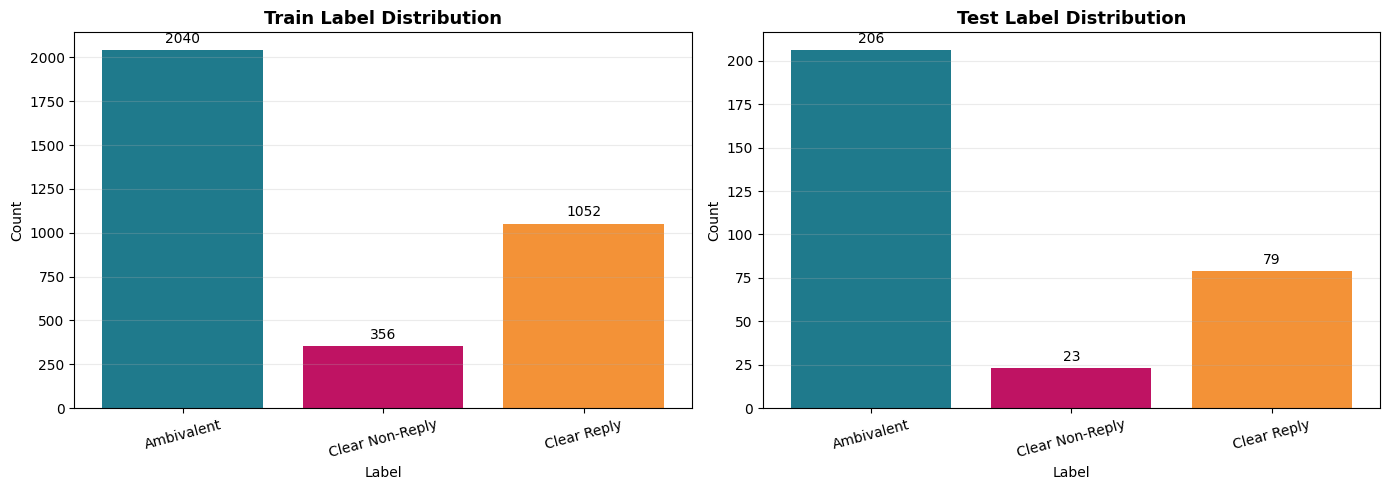

In [5]:
fig, axes = plt.subplots(1, 2, figsize = (14, 5))
colors = ['#1f7a8c', '#bf1363', '#f39237']

for ax, (name, df) in zip(axes, [('Train', train_df), ('Test', test_df)]):
    counts = df['clarity_label'].value_counts().sort_index()
    ax.bar(counts.index, counts.values, color = colors)
    ax.set_title(f'{name} Label Distribution', fontsize = 13, fontweight = 'bold')
    ax.set_xlabel('Label')
    ax.set_ylabel('Count')
    ax.tick_params(axis = 'x', rotation = 15)
    ax.grid(axis = 'y', alpha = 0.25)
    for idx, (_, count) in enumerate(counts.items()):
        ax.text(idx, count + max(counts) * 0.02, str(count), ha = 'center')

plt.tight_layout()
plt.show()

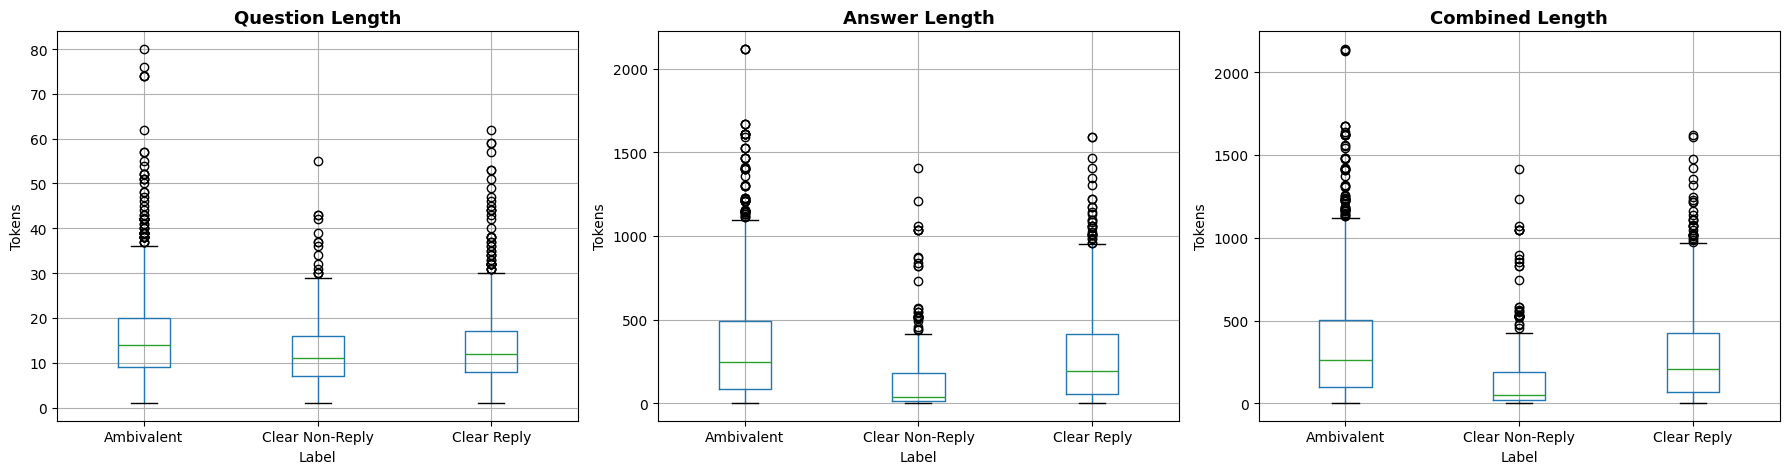

,question_len,answer_len,total_len
count,3448.00,3448.00,3448.00
mean,14.46,293.57,308.03
std,8.83,301.54,303.76
min,1.00,1.00,2.00
25%,8.00,56.00,68.00
50%,12.00,207.00,222.00
75%,19.00,440.00,457.00
max,80.00,2117.00,2140.00


In [6]:
for df in (train_df, test_df):
    df['question_len'] = df['question'].fillna('').str.split().str.len()
    df['answer_len'] = df['interview_answer'].fillna('').str.split().str.len()
    df['total_len'] = df['question_len'] + df['answer_len']

fig, axes = plt.subplots(1, 3, figsize = (18, 5))
for ax, column, title in zip(
    axes,
    ['question_len', 'answer_len', 'total_len'],
    ['Question Length', 'Answer Length', 'Combined Length'],
):
    train_df.boxplot(column = column, by = 'clarity_label', ax = ax)
    ax.set_title(title, fontsize = 13, fontweight = 'bold')
    ax.set_xlabel('Label')
    ax.set_ylabel('Tokens')

plt.suptitle('')
plt.tight_layout()
plt.show()

train_df[['question_len', 'answer_len', 'total_len']].describe().round(2)

## 5. Minimal Pipeline Framework

We reuse the same idea as HW1: a thin classifier wrapper coordinates preprocessing, source encoding, target encoding, model fitting, prediction, and scoring.

In [7]:
class IdentityPreprocessor:
    def __call__(self, source):
        return source


class Classifier(
    sklearn.base.BaseEstimator,
    sklearn.base.ClassifierMixin,
):
    def __init__(self, preprocessor, model, source_encoder, target_bicoder, scorers = None):
        self.preprocessor = preprocessor
        self.model = model
        self.source_encoder = source_encoder
        self.target_bicoder = target_bicoder
        self.scorers = scorers or {}

    def compile(self, **scorers):
        self.scorers = scorers
        return self

    def preprocess(self, source):
        return self.preprocessor(source)

    def fit(self, source, target, /):
        source = self.preprocess(source)
        self.source_encoder.fit(source, target)
        self.target_bicoder.fit(target)
        self.model.fit(
            self.source_encoder.transform(source),
            self.target_bicoder.transform(target),
        )
        return self

    def forward(self, source):
        return self.model.predict(
            self.source_encoder.transform(self.preprocess(source))
        )

    def predict(self, source):
        return self.target_bicoder.inverse_transform(self.forward(source))

    def score(self, source, target, /):
        true = self.target_bicoder.transform(target)
        pred = self.forward(source)
        return {
            name: scorer(true, pred)
            for name, scorer in self.scorers.items()
        }

## 6. Transformer Components

Only the source encoder and the model change relative to HW1:

- `TokenizerEncoder` turns `(question, answer)` into transformer inputs
- `TransformerModel` fine-tunes a pretrained sequence classifier with a small explicit training loop

The training loop is intentionally simple: `AdamW`, weighted cross-entropy, gradient clipping, one fixed stratified validation split, and best-checkpoint restoration by validation macro F1.

In [8]:
class ClarityDataset(torch.utils.data.Dataset):
    """PyTorch dataset wrapping tokenized question-answer pairs."""

    def __init__(self, encodings, labels = None):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.encodings['input_ids'])

    def __getitem__(self, idx):
        item = {key: value[idx] for key, value in self.encodings.items()}
        if self.labels is not None:
            item['labels'] = self.labels[idx]
        return item


class TokenizerEncoder(
    sklearn.base.BaseEstimator,
    sklearn.base.TransformerMixin,
):
    """Wrap AutoTokenizer as the sentence-pair encoder."""

    def __init__(self, model_name = 'bert-base-uncased', max_length = 256):
        self.model_name = model_name
        self.max_length = max_length
        self._tokenizer = None

    def fit(self, source, signal = None):
        return self

    def transform(self, source):
        if self._tokenizer is None:
            self._tokenizer = transformers.AutoTokenizer.from_pretrained(self.model_name)

        encoding = self._tokenizer(
            source['question'].tolist(),
            source['answer'].tolist(),
            padding = True,
            truncation = True,
            max_length = self.max_length,
            return_tensors = 'pt',
        )
        return dict(encoding)


class TransformerModel(sklearn.base.BaseEstimator):
    """Wrap transformer fine-tuning in the shared Classifier pipeline."""

    def __init__(
        self,
        model_name = 'bert-base-uncased',
        num_labels = 3,
        batch_size = 16,
        learning_rate = 2e-5,
        weight_decay = 0.01,
        num_epochs = 4,
        max_grad_norm = 1.0,
        class_weights = None,
        val_frac = 0.15,
        device = DEVICE,
    ):
        self.model_name = model_name
        self.num_labels = num_labels
        self.batch_size = batch_size
        self.learning_rate = learning_rate
        self.weight_decay = weight_decay
        self.num_epochs = num_epochs
        self.max_grad_norm = max_grad_norm
        self.class_weights = class_weights
        self.val_frac = val_frac
        self.device = device

        self._model = None
        self.history = {}
        self.best_val_f1_ = 0.0
        self.best_epoch_ = 0

    def _build(self):
        require_cuda()
        self._model = transformers.AutoModelForSequenceClassification.from_pretrained(
            self.model_name,
            num_labels = self.num_labels,
        ).to(self.device)

    def _model_dtype(self):
        if self._model is None:
            return torch.float32
        return next(self._model.parameters()).dtype

    def _make_loss_fn(self):
        weights = None
        if self.class_weights is not None:
            weights = self.class_weights.to(device = self.device, dtype = self._model_dtype())
        return torch.nn.CrossEntropyLoss(weight = weights)

    def _split_train_validation(self, source, labels):
        indices = np.arange(len(labels))
        train_idx, val_idx = sklearn.model_selection.train_test_split(
            indices,
            test_size = self.val_frac,
            random_state = RANDOM_STATE,
            stratify = labels.cpu().numpy(),
        )

        train_enc = {key: value[train_idx] for key, value in source.items()}
        val_enc = {key: value[val_idx] for key, value in source.items()}
        train_labels = labels[train_idx]
        val_labels = labels[val_idx]
        return train_enc, train_labels, val_enc, val_labels

    def fit(self, source, target, /):
        if self._model is None:
            self._build()

        labels = target if isinstance(target, torch.Tensor) else torch.tensor(target, dtype = torch.long)
        train_enc, train_labels, val_enc, val_labels = self._split_train_validation(source, labels)

        train_loader = torch.utils.data.DataLoader(
            ClarityDataset(train_enc, train_labels),
            batch_size = self.batch_size,
            shuffle = True,
            pin_memory = True,
        )

        optimizer = torch.optim.AdamW(
            self._model.parameters(),
            lr = self.learning_rate,
            weight_decay = self.weight_decay,
        )
        loss_fn = self._make_loss_fn()

        self.history = {'train_loss': [], 'val_loss': [], 'val_f1': []}
        self.best_val_f1_ = 0.0
        self.best_epoch_ = 0
        best_state = None

        for epoch in range(self.num_epochs):
            self._model.train()
            total_loss = 0.0

            for batch in train_loader:
                optimizer.zero_grad()
                model_inputs = {
                    key: value.to(self.device, non_blocking = True)
                    for key, value in batch.items()
                    if key != 'labels'
                }
                labels_batch = batch['labels'].to(self.device, non_blocking = True)

                outputs = self._model(**model_inputs)
                loss = loss_fn(outputs.logits, labels_batch)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self._model.parameters(), self.max_grad_norm)
                optimizer.step()

                total_loss += float(loss.item())

            avg_train_loss = total_loss / len(train_loader)
            val_metrics = self._evaluate(val_enc, val_labels)

            self.history['train_loss'].append(avg_train_loss)
            self.history['val_loss'].append(val_metrics['loss'])
            self.history['val_f1'].append(val_metrics['f1'])

            improved = val_metrics['f1'] > self.best_val_f1_
            if improved:
                self.best_val_f1_ = val_metrics['f1']
                self.best_epoch_ = epoch + 1
                best_state = {
                    key: value.detach().cpu().clone()
                    for key, value in self._model.state_dict().items()
                }

            print(
                f"Epoch {epoch + 1}/{self.num_epochs} | "
                f"Train Loss: {avg_train_loss:.4f} | "
                f"Val Loss: {val_metrics['loss']:.4f} | "
                f"Val F1: {val_metrics['f1']:.4f}"
                f"{'  *' if improved else ''}"
            )

        if best_state is not None:
            self._model.load_state_dict(best_state)
            self._model.to(self.device)
            print(f"Restored best checkpoint from epoch {self.best_epoch_} (Val F1: {self.best_val_f1_:.4f})")

        return self

    @torch.no_grad()
    def _evaluate(self, encodings, labels):
        self._model.eval()

        loader = torch.utils.data.DataLoader(
            ClarityDataset(encodings, labels),
            batch_size = self.batch_size,
            shuffle = False,
            pin_memory = True,
        )
        loss_fn = self._make_loss_fn()
        total_loss = 0.0
        predictions = []

        for batch in loader:
            model_inputs = {
                key: value.to(self.device, non_blocking = True)
                for key, value in batch.items()
                if key != 'labels'
            }
            labels_batch = batch['labels'].to(self.device, non_blocking = True)

            outputs = self._model(**model_inputs)
            total_loss += float(loss_fn(outputs.logits, labels_batch).item())
            predictions.extend(outputs.logits.argmax(dim = -1).cpu().tolist())

        true = labels.cpu().numpy()
        pred = np.array(predictions)
        return {
            'loss': total_loss / len(loader),
            'f1': float(sklearn.metrics.f1_score(true, pred, average = 'macro', zero_division = 0)),
        }

    @torch.no_grad()
    def predict(self, source, /):
        self._model.eval()

        loader = torch.utils.data.DataLoader(
            ClarityDataset(source),
            batch_size = self.batch_size,
            shuffle = False,
            pin_memory = True,
        )
        predictions = []

        for batch in loader:
            model_inputs = {
                key: value.to(self.device, non_blocking = True)
                for key, value in batch.items()
            }
            outputs = self._model(**model_inputs)
            predictions.extend(outputs.logits.argmax(dim = -1).cpu().tolist())

        return np.array(predictions)


def macro_averaged(metric_fn, **kwargs):
    """Wrap an sklearn metric with macro averaging and zero_division=0."""
    return functools.partial(
        metric_fn,
        average = 'macro',
        zero_division = 0,
        **kwargs,
    )


In [9]:
def data_prep(train_df, test_df):
    """Prepare question-answer pairs for transformer sentence-pair encoding."""
    X_train = pd.DataFrame({
        'question': train_df['question'].fillna('').str.strip(),
        'answer': train_df['interview_answer'].fillna('').str.strip(),
    })
    y_train = train_df['clarity_label'].fillna('').str.strip()

    X_test = pd.DataFrame({
        'question': test_df['question'].fillna('').str.strip(),
        'answer': test_df['interview_answer'].fillna('').str.strip(),
    })
    y_test = test_df['clarity_label'].fillna('').str.strip()

    return X_train, y_train, X_test, y_test



def compute_class_weights(labels, num_classes = 3):
    """Compute balanced class weights using sklearn's formula."""
    counts = torch.bincount(labels, minlength = num_classes).float()
    return len(labels) / (num_classes * counts)



def make_label_encoder(y_train):
    """Fit the label encoder and compute training class weights."""
    label_encoder = sklearn.preprocessing.LabelEncoder()
    label_encoder.fit(y_train)

    encoded = torch.tensor(label_encoder.transform(y_train), dtype = torch.long)
    class_weights = compute_class_weights(encoded, num_classes = len(label_encoder.classes_))

    return label_encoder, class_weights



def make_classifier(model_name, label_encoder, class_weights, config):
    """Create the shared pipeline with transformer-specific components."""
    classifier = Classifier(
        preprocessor = IdentityPreprocessor(),
        model = TransformerModel(
            model_name = model_name,
            num_labels = 3,
            batch_size = int(config['batch_size']),
            learning_rate = float(config['learning_rate']),
            weight_decay = float(config['weight_decay']),
            num_epochs = int(config['num_epochs']),
            max_grad_norm = float(config['max_grad_norm']),
            class_weights = class_weights,
            val_frac = float(config['val_frac']),
            device = require_cuda(),
        ),
        source_encoder = TokenizerEncoder(
            model_name = model_name,
            max_length = int(config['max_length']),
        ),
        target_bicoder = label_encoder,
    )

    classifier.compile(
        accuracy = sklearn.metrics.accuracy_score,
        precision = macro_averaged(sklearn.metrics.precision_score),
        recall = macro_averaged(sklearn.metrics.recall_score),
        f1 = macro_averaged(sklearn.metrics.f1_score),
    )

    return classifier



def submission_filename(model_name):
    """Return the Kaggle submission filename required by HW2."""
    return f"submission {model_name.replace('/', '-')}.csv"


In [10]:
def run_tiny_sweep(model_name, X_train, y_train, class_weights, label_encoder):
    results = []
    for num_epochs, max_length in itertools.product(SWEEP_GRID['num_epochs'], SWEEP_GRID['max_length']):
        seed_everything(RANDOM_STATE)
        config = dict(DEFAULT_CONFIG)
        config['num_epochs'] = num_epochs
        config['max_length'] = max_length

        print(f"\nTrying epochs={num_epochs}, max_length={max_length}")
        classifier = make_classifier(model_name, label_encoder, class_weights, config)
        classifier.fit(X_train, y_train)
        model = classifier.model
        results.append({
            'model': model_name,
            'num_epochs': num_epochs,
            'max_length': max_length,
            'best_epoch': model.best_epoch_,
            'val_f1': model.best_val_f1_,
        })

    results_df = pd.DataFrame(results).sort_values(
        by = ['val_f1', 'max_length', 'num_epochs'],
        ascending = [False, False, False],
    ).reset_index(drop = True)
    best_row = results_df.iloc[0]
    best_config = dict(DEFAULT_CONFIG)
    best_config['num_epochs'] = int(best_row['num_epochs'])
    best_config['max_length'] = int(best_row['max_length'])
    sweep_path = f"{model_name.replace('/', '-')}_sanity_sweep.csv"
    results_df.to_csv(sweep_path, index = False)
    print(f"Saved sweep summary to {sweep_path}")
    return results_df, best_config

## 7. Input Construction and Labels

The input is a DataFrame with two columns, `question` and `answer`. The tokenizer converts that pair into the model's native sentence-pair format. Class weights are computed from the training labels to partially offset class imbalance.

In [11]:
X_train, y_train, X_test, y_test = data_prep(train_df, test_df)
label_encoder, class_weights = make_label_encoder(y_train)

print(f'Training examples: {len(X_train)}')
print(f'Test examples:     {len(X_test)}')
print(f'Labels:            {list(label_encoder.classes_)}')
print(f'Class weights:     {dict(zip(label_encoder.classes_, class_weights.tolist()))}')

Training examples: 3448
Test examples:     308
Labels:            ['Ambivalent', 'Clear Non-Reply', 'Clear Reply']
Class weights:     {'Ambivalent': 0.5633987188339233, 'Clear Non-Reply': 3.228464365005493, 'Clear Reply': 1.092522144317627}


## 8. Validation Strategy and Tiny Sweep

We do **not** use 3-fold cross-validation in HW2. Transformer training is much heavier than the classical models from HW1, so we use one fixed 15% stratified validation split inside the training loop.

For the selected model, we run the same 2 x 3 sanity sweep over `epochs` and `max_length`. This keeps the tuning budget uniform across BERT, DistilBERT, and DeBERTa.

In [12]:
seed_everything(RANDOM_STATE)
SWEEP_RESULTS, FINAL_CONFIG = run_tiny_sweep(
    MODEL_NAME,
    X_train,
    y_train,
    class_weights,
    label_encoder,
)
display(SWEEP_RESULTS)


Trying epochs=3, max_length=128


config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

...

Epoch 1/4 | Train Loss: nan | Val Loss: nan | Val F1: 0.2476  *
Epoch 2/4 | Train Loss: nan | Val Loss: nan | Val F1: 0.2476
Epoch 3/4 | Train Loss: nan | Val Loss: nan | Val F1: 0.2476
Epoch 4/4 | Train Loss: nan | Val Loss: nan | Val F1: 0.2476
Restored best checkpoint from epoch 1 (Val F1: 0.2476)

Trying epochs=4, max_length=384


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
pooler.dense.bias                       | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifier.weight                       | MISSING    | 
classifier.bias          

Epoch 1/4 | Train Loss: nan | Val Loss: nan | Val F1: 0.2476  *
Epoch 2/4 | Train Loss: nan | Val Loss: nan | Val F1: 0.2476
Epoch 3/4 | Train Loss: nan | Val Loss: nan | Val F1: 0.2476
Epoch 4/4 | Train Loss: nan | Val Loss: nan | Val F1: 0.2476
Restored best checkpoint from epoch 1 (Val F1: 0.2476)
Saved sweep summary to microsoft-deberta-v3-base_sanity_sweep.csv


,model,num_epochs,max_length,best_epoch,val_f1
0,microsoft/deberta-v3-base,4,384,1,0.247573
1,microsoft/deberta-v3-base,3,384,1,0.247573
2,microsoft/deberta-v3-base,4,256,1,0.247573
3,microsoft/deberta-v3-base,3,256,1,0.247573
4,microsoft/deberta-v3-base,4,128,1,0.247573
5,microsoft/deberta-v3-base,3,128,1,0.247573


## 9. Final Training Run

Now we train the selected model on the official training split, using the fixed validation split only for model selection during training.

In [13]:
seed_everything(RANDOM_STATE)
classifier = make_classifier(MODEL_NAME, label_encoder, class_weights, FINAL_CONFIG)

print(f'Model:         {MODEL_NAME}')
print(f'Device:        {require_cuda()}')
print(f'Max length:    {FINAL_CONFIG["max_length"]}')
print(f'Batch size:    {FINAL_CONFIG["batch_size"]}')
print(f'Learning rate: {FINAL_CONFIG["learning_rate"]}')
print(f'Weight decay:  {FINAL_CONFIG["weight_decay"]}')
print(f'Epochs:        {FINAL_CONFIG["num_epochs"]}')
print(f'Val fraction:  {FINAL_CONFIG["val_frac"]}')
print()

classifier.fit(X_train, y_train)

Model:         microsoft/deberta-v3-base
Device:        cuda
Max length:    384
Batch size:    16
Learning rate: 2e-05
Weight decay:  0.01
Epochs:        4
Val fraction:  0.15



Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
pooler.dense.bias                       | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifier.weight                       | MISSING    | 
classifier.bias          

Epoch 1/4 | Train Loss: nan | Val Loss: nan | Val F1: 0.2476  *
Epoch 2/4 | Train Loss: nan | Val Loss: nan | Val F1: 0.2476
Epoch 3/4 | Train Loss: nan | Val Loss: nan | Val F1: 0.2476
Epoch 4/4 | Train Loss: nan | Val Loss: nan | Val F1: 0.2476
Restored best checkpoint from epoch 1 (Val F1: 0.2476)


Classifier(model=TransformerModel(class_weights=tensor([0.5634, 3.2285, 1.0925]),
                                  model_name='microsoft/deberta-v3-base'),
           preprocessor=<__main__.IdentityPreprocessor object at 0x78e4dd6b39b0>,
           scorers={'accuracy': <function accuracy_score at 0x78e5502f7ce0>,
                    'f1': functools.partial(<function f1_score at 0x78e5503285e0>, average='macro', zero_division=0),
                    'precision': functools.partial(<function precision_score at 0x78e550328e00>, average='macro', zero_division=0),
                    'recall': functools.partial(<function recall_score at 0x78e550328f40>, average='macro', zero_division=0)},
           source_encoder=TokenizerEncoder(max_length=384,
                                           model_name='microsoft/deberta-v3-base'),
           target_bicoder=LabelEncoder())

## 10. Test Evaluation

We report the same metrics as HW1: accuracy, macro precision, macro recall, and macro F1.

In [14]:
test_scores = classifier.score(X_test, y_test)
y_pred = classifier.predict(X_test)

display(pd.DataFrame([test_scores]).round(4))

print('Per-class report:')
print(sklearn.metrics.classification_report(y_test, y_pred, digits = 4))

,accuracy,precision,recall,f1
0,0.6688,0.2229,0.3333,0.2672


Per-class report:
                 precision    recall  f1-score   support

     Ambivalent     0.6688    1.0000    0.8016       206
Clear Non-Reply     0.0000    0.0000    0.0000        23
    Clear Reply     0.0000    0.0000    0.0000        79

       accuracy                         0.6688       308
      macro avg     0.2229    0.3333    0.2672       308
   weighted avg     0.4473    0.6688    0.5361       308



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


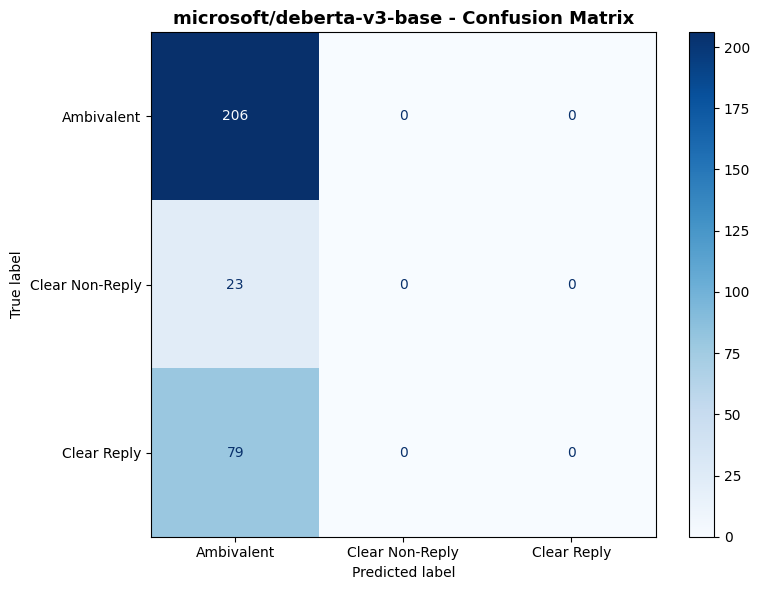

In [15]:
cm = sklearn.metrics.confusion_matrix(y_test, y_pred, labels = label_encoder.classes_)
disp = sklearn.metrics.ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels = label_encoder.classes_,
)
fig, ax = plt.subplots(figsize = (8, 6))
disp.plot(ax = ax, cmap = 'Blues', values_format = 'd')
ax.set_title(f'{MODEL_NAME} - Confusion Matrix', fontsize = 13, fontweight = 'bold')
ax.grid(False)
plt.tight_layout()
plt.show()

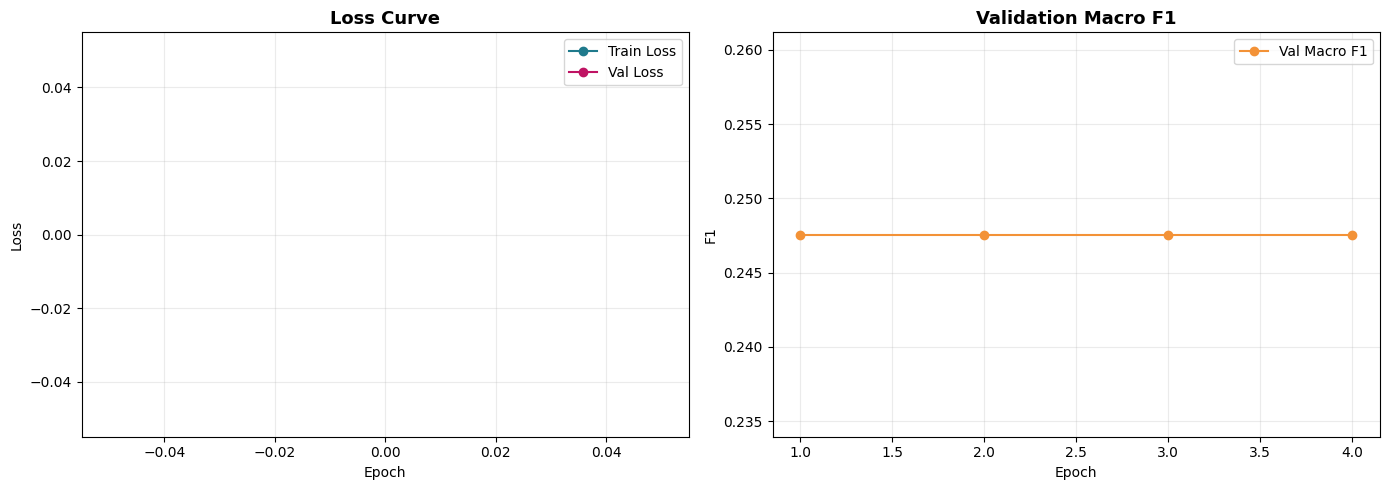

In [16]:
model = classifier.model
epochs = range(1, len(model.history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize = (14, 5))
axes[0].plot(epochs, model.history['train_loss'], marker = 'o', color = '#1f7a8c', label = 'Train Loss')
axes[0].plot(epochs, model.history['val_loss'], marker = 'o', color = '#bf1363', label = 'Val Loss')
axes[0].set_title('Loss Curve', fontsize = 13, fontweight = 'bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(alpha = 0.25)
axes[0].legend()

axes[1].plot(epochs, model.history['val_f1'], marker = 'o', color = '#f39237', label = 'Val Macro F1')
axes[1].set_title('Validation Macro F1', fontsize = 13, fontweight = 'bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1')
axes[1].grid(alpha = 0.25)
axes[1].legend()

plt.tight_layout()
plt.show()

## 11. Subgroup Analysis by Text Length

The assignment asks for analysis across different data subgroups. We group test examples by question length and answer length and compare macro F1 across those buckets.

In [17]:
def make_length_bucket(series):
    q1, q2 = series.quantile([0.33, 0.67])
    return pd.cut(
        series,
        bins = [-np.inf, q1, q2, np.inf],
        labels = ['short', 'medium', 'long'],
        include_lowest = True,
    )


def subgroup_scores(df, group_col):
    rows = []
    for group_name, group_df in df.groupby(group_col):
        rows.append({
            'group': group_name,
            'count': len(group_df),
            'accuracy': sklearn.metrics.accuracy_score(group_df['true'], group_df['pred']),
            'macro_f1': sklearn.metrics.f1_score(group_df['true'], group_df['pred'], average = 'macro', zero_division = 0),
        })
    return pd.DataFrame(rows).sort_values('group').reset_index(drop = True)

analysis_df = test_df[['question', 'interview_answer', 'clarity_label', 'question_len', 'answer_len']].copy()
analysis_df['pred'] = y_pred
analysis_df['true'] = y_test.to_numpy()
analysis_df['question_bucket'] = make_length_bucket(analysis_df['question_len'])
analysis_df['answer_bucket'] = make_length_bucket(analysis_df['answer_len'])

print('Question-length subgroups')
display(subgroup_scores(analysis_df, 'question_bucket').round(4))
print('Answer-length subgroups')
display(subgroup_scores(analysis_df, 'answer_bucket').round(4))

Question-length subgroups


/tmp/ipykernel_23/2584425322.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group_name, group_df in df.groupby(group_col):


,group,count,accuracy,macro_f1
0,long,94,0.7447,0.2846
1,medium,107,0.7477,0.2852
2,short,107,0.5234,0.2290


Answer-length subgroups


/tmp/ipykernel_23/2584425322.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group_name, group_df in df.groupby(group_col):


,group,count,accuracy,macro_f1
0,long,102,0.7843,0.2930
1,medium,104,0.6731,0.2682
2,short,102,0.5490,0.2363


## 12. Error Analysis

We inspect the most common confusions and show representative mistakes. This is where you should add short qualitative observations after running the notebook.

In [18]:
errors = analysis_df.loc[analysis_df['true'] != analysis_df['pred']].copy()
errors['pair'] = errors['true'] + ' -> ' + errors['pred']

print(f'Total errors: {len(errors)} / {len(analysis_df)}')
display(errors['pair'].value_counts().rename_axis('confusion').reset_index(name = 'count'))

example_columns = ['true', 'pred', 'question', 'interview_answer', 'question_len', 'answer_len']
display(errors[example_columns].head(8))

Total errors: 102 / 308


,confusion,count
0,Clear Reply -> Ambivalent,79
1,Clear Non-Reply -> Ambivalent,23


,true,pred,question,interview_answer,question_len,answer_len
11,Clear Reply,Ambivalent,Shape of the multinational force,"In terms of the troops, that's what the meetin...",5,193
13,Clear Reply,Ambivalent,What have they achieved and what will they lea...,"Okay, I will start answering. Has it become be...",13,327
15,Clear Reply,Ambivalent,Messages for the Governments of Iran and Syria,"Want me to start? My message is, give up your ...",8,382
21,Clear Reply,Ambivalent,Was this coordinated with you?,"No, it wasn't coordinated with me, and my pati...",5,258
29,Clear Non-Reply,Ambivalent,"Mr. President, if the EU does not receive a de...",I said I wasn't going to answer a hypothetical...,39,317
30,Clear Reply,Ambivalent,New Policy on Intercepting North Korean Ships,"Well, this is not simply a U.S. policy; this i...",7,246
32,Clear Non-Reply,Ambivalent,Why would you agree with Senator McCain or Sen...,"No, I appreciate you trying to drag me in the ...",10,128
36,Clear Reply,Ambivalent,Is it no longer important to track him down?,"It's just an incorrect story. I mean, we got a...",9,30


## 13. Submission File

Each required notebook must write the exact model-specific CSV filename requested in the specification.

In [19]:
submission = pd.Series(y_pred, name = 'Predicted')
submission.index.name = 'Id'
submission_path = submission_filename(MODEL_NAME)
submission.to_csv(submission_path)

print(f'Saved: {submission_path}')
print('Prediction distribution:')
print(submission.value_counts())
submission.head(10)

Saved: submission microsoft-deberta-v3-base.csv
Prediction distribution:
Predicted
Ambivalent    308
Name: count, dtype: int64


Id
0    Ambivalent
1    Ambivalent
2    Ambivalent
3    Ambivalent
4    Ambivalent
5    Ambivalent
6    Ambivalent
7    Ambivalent
8    Ambivalent
9    Ambivalent
Name: Predicted, dtype: object

## 14. Comparison to HW1

We do not rerun the classical baselines here. Instead, we reference the best results already reported in HW1 and compare the current transformer result against them.

In [20]:
hw1_reference = pd.DataFrame([
    {'model': 'HW1 TF-IDF + Logistic Regression', 'macro_f1_reference': 0.45},
    {'model': 'HW1 GloVe Wiki + Logistic Regression', 'macro_f1_reference': 0.39},
    {'model': 'HW1 GloVe Twitter + Logistic Regression', 'macro_f1_reference': 0.38},
])

current_result = pd.DataFrame([
    {'model': MODEL_NAME, 'macro_f1': test_scores['f1'], 'accuracy': test_scores['accuracy']}
]).round(4)

print('HW1 reference results from the previous assignment report:')
display(hw1_reference)
print('Current HW2 result:')
display(current_result)

HW1 reference results from the previous assignment report:


,model,macro_f1_reference
0,HW1 TF-IDF + Logistic Regression,0.45
1,HW1 GloVe Wiki + Logistic Regression,0.39
2,HW1 GloVe Twitter + Logistic Regression,0.38


Current HW2 result:


,model,macro_f1,accuracy
0,microsoft/deberta-v3-base,0.2672,0.6688


## 15. Conclusion

After execution, replace this short checklist with your run-specific conclusions:

- Did contextual fine-tuning improve on the HW1 TF-IDF baseline?
- Which class remained hardest to predict?
- Did short or long answers cause more failures?
- Did the small 2 x 3 sweep materially change the final recipe for this model?
- Why does contextual encoding help more than averaged word vectors on this task?